# NSW Active-Fire Reliability Pilot - Exploratory Data Analysis (EDA)

This notebook conducts a baseline exploratory data analysis (EDA) on the satellite active-fire hotspot observation dataset and historical fire boundary polygons. The purpose is to map their spatial distribution, understand temporal ranges, evaluate data quality (duplicates, missingness, and ranges), and establish key insights about structural skewness before applying spatiotemporal matching models.

## 1. Setup and Environment Check

We verify standard package versions to ensure reproducible executions.

In [1]:
# Execution Configuration
EXECUTION_MODE = "snapshot"  # Options: "snapshot"
SNAPSHOT_SLUG = "tuannm3812/nsw-active-fire-pilot-snapshot"

import json
import os
from pathlib import Path
from datetime import datetime, timezone
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from importlib.metadata import version
print("Runtime Environment:")
for pkg in ["pandas", "numpy", "matplotlib", "nbformat"]:
    try:
        print(f"- {pkg}: {version(pkg)}")
    except Exception:
        print(f"- {pkg}: not installed")


Runtime Environment:
- pandas: 2.3.3
- numpy: 2.0.2
- matplotlib: 3.9.4
- nbformat: 5.10.4


## 2. Data Loading & Schema Discovery

We dynamically search for our staged datasets in Kaggle mount paths or local fallbacks, loading Geoscience Australia's DEA Hotspots and NSW National Parks & Wildlife Service's (NPWS) Fire History layers.

In [2]:
# Locate and load the snapshot dataset
dataset_dir = None
for root, dirs, files in os.walk('/kaggle/input'):
    if 'dea_hotspots.geojson' in files:
        dataset_dir = Path(root)
        print(f"Found dataset at: {dataset_dir}")
        break
if dataset_dir is None:
    for root, dirs, files in os.walk('../input'):
        if 'dea_hotspots.geojson' in files:
            dataset_dir = Path(root)
            print(f"Found dataset at: {dataset_dir}")
            break
if dataset_dir is None:
    curr = Path('.').resolve()
    for parent in [curr] + list(curr.parents):
        candidate = parent / 'output' / 'kaggle' / 'active-fire-pilot'
        if (candidate / 'dea_hotspots.geojson').is_file():
            dataset_dir = candidate
            print(f"Found local repository dataset at: {dataset_dir}")
            break
if dataset_dir is None:
    dataset_dir = Path('.')
    print(f"Dataset not found. Falling back to current directory: {dataset_dir}")

dea_path = dataset_dir / 'dea_hotspots.geojson'
npws_path = dataset_dir / 'npws_fire_history.geojson'

print('Loading spatial datasets...')
with open(dea_path) as f:
    dea_data = json.load(f)
with open(npws_path) as f:
    npws_data = json.load(f)

print(f"Loaded {len(dea_data['features']):,} hotspots and {len(npws_data['features']):,} fire polygons.")

Found local repository dataset at: /Users/tuannm3812/Documents/GitHub/1. Study/uts-mdsi/output/kaggle/active-fire-pilot
Loading spatial datasets...
Loaded 19,849 hotspots and 14 fire polygons.


## 3. Data Normalization & Cleaning

We parse the geographic GeoJSON attributes into pandas DataFrames, extracting geographic coordinates, timestamps, and sensor categories.

In [3]:
# Normalize datasets into pandas DataFrames
hotspots_list = []
for feature in dea_data['features']:
    props = feature.get('properties', {})
    geom = feature.get('geometry', {})
    coords = geom.get('coordinates', [np.nan, np.nan])
    hotspots_list.append({
        'id': props.get('id'),
        'datetime': pd.to_datetime(props.get('datetime')),
        'longitude': props.get('longitude', coords[0]),
        'latitude': props.get('latitude', coords[1]),
        'sensor': props.get('sensor'),
        'satellite': props.get('satellite'),
        'temp_kelvin': props.get('temp_kelvin'),
        'power': props.get('power'),
        'confidence': props.get('confidence'),
        'accuracy': props.get('accuracy'),
    })
df_hotspots = pd.DataFrame(hotspots_list)

fires_list = []
for feature in npws_data['features']:
    props = feature.get('properties', {})
    fires_list.append({
        'fire_id': props.get('FireNo') or str(props.get('OBJECTID')),
        'fire_name': props.get('FireName') or 'Unnamed',
        'ignition_date': pd.to_datetime(props.get('StartDate')),
        'extinguish_date': pd.to_datetime(props.get('EndDate')),
        'area_ha': props.get('AreaHa'),
        'perimeter_m': props.get('PerimeterM')
    })
df_fires = pd.DataFrame(fires_list)

print('Hotspots schema check:')
df_hotspots.info()
print('\nFires schema check:')
df_fires.info()

Hotspots schema check:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19849 entries, 0 to 19848
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype              
---  ------       --------------  -----              
 0   id           19849 non-null  int64              
 1   datetime     19849 non-null  datetime64[ns, UTC]
 2   longitude    19849 non-null  float64            
 3   latitude     19849 non-null  float64            
 4   sensor       19849 non-null  object             
 5   satellite    19849 non-null  object             
 6   temp_kelvin  19841 non-null  float64            
 7   power        19783 non-null  float64            
 8   confidence   19849 non-null  int64              
 9   accuracy     19849 non-null  object             
dtypes: datetime64[ns, UTC](1), float64(4), int64(2), object(3)
memory usage: 1.5+ MB

Fires schema check:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 6 columns):
 #   Column

## 4. Data Quality & Profiling

We audit duplicates, spatial boundaries, and missing values in the datasets.

In [4]:
print('=== GEOGRAPHIC BOUNDS ===')
print(f"Latitude range: {df_hotspots['latitude'].min():.4f} to {df_hotspots['latitude'].max():.4f}")
print(f"Longitude range: {df_hotspots['longitude'].min():.4f} to {df_hotspots['longitude'].max():.4f}")

print('\n=== DUPLICATE OBSERVATIONS ===')
duplicates = df_hotspots.duplicated(subset=['longitude', 'latitude', 'datetime']).sum()
print(f"Duplicate hotspots (identical pos/time): {duplicates:,} out of {len(df_hotspots):,}")

print('\n=== MISSINGNESS RATE ===')
print(df_hotspots.isnull().sum())

print('\n=== MISSING CONFIDENCE BY SENSOR ===')
print(df_hotspots.groupby('sensor')['confidence'].apply(lambda x: x.isnull().mean() * 100).round(2))

=== GEOGRAPHIC BOUNDS ===
Latitude range: -33.6986 to -32.3019
Longitude range: 149.5280 to 151.0000

=== DUPLICATE OBSERVATIONS ===
Duplicate hotspots (identical pos/time): 8 out of 19,849

=== MISSINGNESS RATE ===
id              0
datetime        0
longitude       0
latitude        0
sensor          0
satellite       0
temp_kelvin     8
power          66
confidence      0
accuracy        0
dtype: int64

=== MISSING CONFIDENCE BY SENSOR ===
sensor
AHI      0.0
AVHRR    0.0
MODIS    0.0
VIIRS    0.0
Name: confidence, dtype: float64


## 5. Data Skewness & Complex Footprints

Before executing the matching pipeline, we must analyze the distribution of the target fire boundaries to understand the scale of the events:

In [5]:
print('Fire area statistics (hectares):')
display(df_fires.sort_values(by='area_ha', ascending=False)[['fire_name', 'area_ha', 'ignition_date']])

Fire area statistics (hectares):


,fire_name,area_ha,ignition_date
12,Gospers Mountain,479513.854369,1970-01-01 00:26:12.008400
11,Kerry Ridge,183646.959774,1970-01-01 00:26:14.427600
10,Little L Complex,136285.783541,1970-01-01 00:26:14.600400
9,Three Mile,48215.550127,1970-01-01 00:26:14.686800
1,Grose Valley,19895.552675,1970-01-01 00:26:16.800000
2,"Upper Turon Rd, Palmers Oaky",17373.433451,1970-01-01 00:26:15.378000
8,Meads Creek West,14128.032569,1970-01-01 00:26:14.686800
4,Woodlands,203.194782,1970-01-01 00:26:18.574800
3,Spring Gully,109.068812,1970-01-01 00:26:18.574800
13,Grose Valley,20.514350,1970-01-01 00:26:16.800000


### Key EDA Takeaways:
1. **Severe Area Skewness:** The dataset is highly skewed. The two largest complexes—**Gospers Mountain** (479,514 ha) and **Kerry Ridge** (183,647 ha)—together account for over 660,000 hectares of burned area. The remaining 12 events are orders of magnitude smaller.
2. **Temporal Dominance:** The active temporal duration of these complexes is extensive. Gospers Mountain, for example, has an active record spanning 107 days (25 Oct 2019 to 9 Feb 2020).
3. **Implications for Matching:** Because of their immense spatial footprints and months-long active windows, these mega-complexes act as massive "spatial-temporal sinks." A random or clustered hotspot within the study bounding box has an extremely high probability of intersecting these polygons by chance. Readers should anticipate that any subsequent matching analysis will be heavily dominated by these two events, requiring held-out validation strategies.

## 6. Spatial Overlays

We plot the fire polygons alongside the raw hotspot coordinates colored by sensor type.

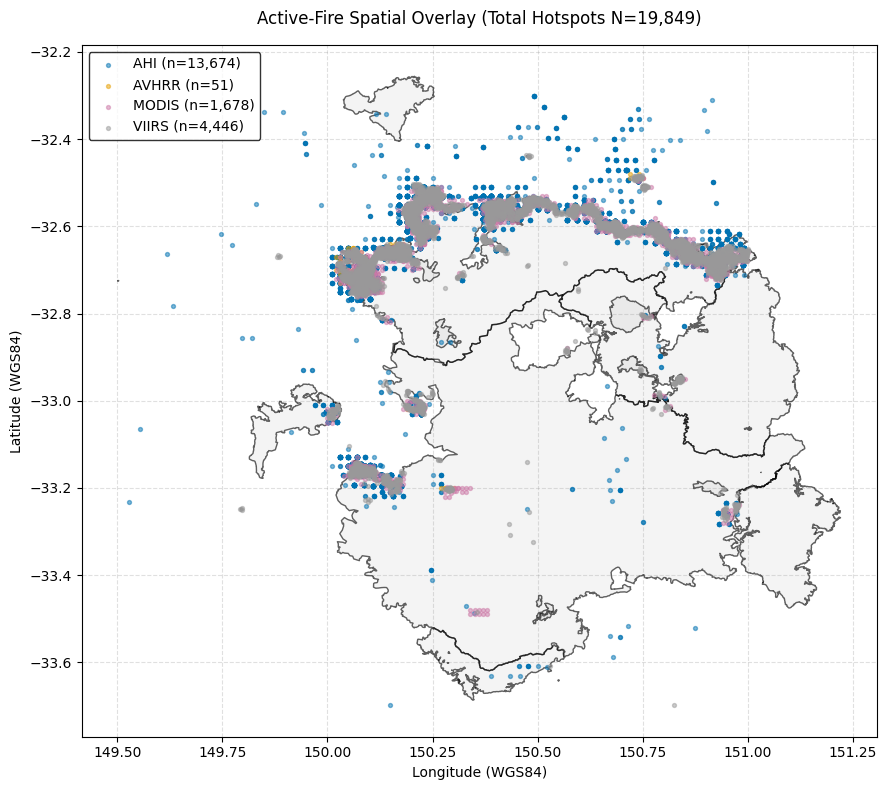

In [6]:
fig, ax = plt.subplots(figsize=(9, 8), facecolor='white')
ax.set_facecolor('white')

OKABE_ITO_COLORS = ['#0072B2', '#E69F00', '#CC79A7', '#999999']
sensors = sorted(df_hotspots['sensor'].dropna().unique())

# 1. Plot boundary outlines
for feature in npws_data['features']:
    geom = feature.get('geometry', {})
    coords = geom.get('coordinates', [])
    poly_list = [coords] if geom.get('type') == 'Polygon' else coords
    for poly in poly_list:
        for ring in poly:
            x = [pt[0] for pt in ring]
            y = [pt[1] for pt in ring]
            ax.plot(x, y, color='black', linewidth=1.0, alpha=0.6, zorder=2)
            ax.fill(x, y, color='#999999', alpha=0.1, zorder=1)

# 2. Scatter plot hotspots per sensor
for idx, sensor in enumerate(sensors):
    subset = df_hotspots[df_hotspots['sensor'] == sensor]
    ax.scatter(subset['longitude'], subset['latitude'], 
               color=OKABE_ITO_COLORS[idx % len(OKABE_ITO_COLORS)], 
               label=f"{sensor} (n={len(subset):,})", s=8, alpha=0.5, zorder=3)

ax.set_xlabel('Longitude (WGS84)')
ax.set_ylabel('Latitude (WGS84)')
ax.set_title(f"Active-Fire Spatial Overlay (Total Hotspots N={len(df_hotspots):,})", fontsize=12, pad=15)
ax.legend(facecolor='white', edgecolor='black')
ax.grid(True, linestyle='--', alpha=0.3, color='#999999')
plt.tight_layout()
plt.show()

### Spatial Visual Interpretation:
- **High Density Regions:** The hotspots are heavily clustered within the outline of the two major mega-complexes.
- **Sensor Footprints:** VIIRS accounts for the highest density of detections due to its high nominal spatial resolution (375m pixels) compared to MODIS's larger footprint (1km pixels). AHI shows a wider, scattered spatial distribution due to its geostationary 2km resolution.

## 7. Attribute Characterization & Skewness

We plot Fire Radiative Power (FRP) vs Temperature and the confidence distributions across sensors.

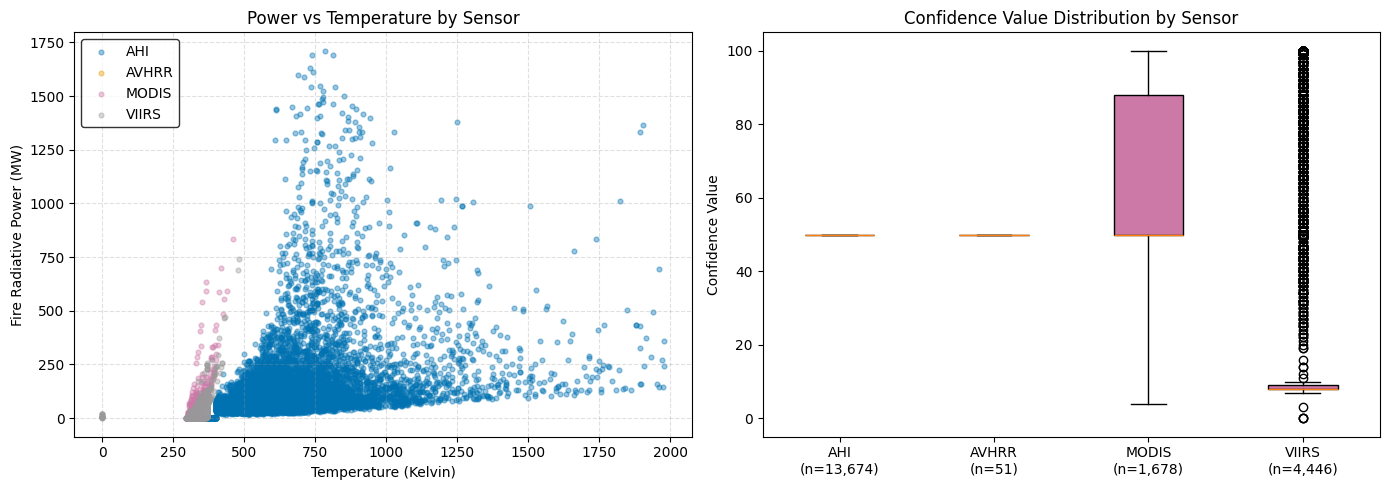

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='white')
for ax in axes:
    ax.set_facecolor('white')

# Left: Scatter plot power vs temperature
for idx, sensor in enumerate(sensors):
    subset = df_hotspots[df_hotspots['sensor'] == sensor]
    axes[0].scatter(subset['temp_kelvin'], subset['power'], 
                    color=OKABE_ITO_COLORS[idx % len(OKABE_ITO_COLORS)], 
                    label=sensor, s=12, alpha=0.4)
axes[0].set_xlabel('Temperature (Kelvin)')
axes[0].set_ylabel('Fire Radiative Power (MW)')
axes[0].set_title('Power vs Temperature by Sensor')
axes[0].legend(facecolor='white', edgecolor='black')
axes[0].grid(True, linestyle='--', alpha=0.3, color='#999999')

# Right: Boxplot of confidence values per sensor
box_data = []
box_labels = []
for sensor in sorted(sensors):
    subset = df_hotspots[df_hotspots['sensor'] == sensor]['confidence'].dropna()
    if not subset.empty:
        box_data.append(subset.values)
        box_labels.append(f"{sensor}\n(n={len(subset):,})")

# Check Matplotlib version for boxplot argument compatibility
import re
import matplotlib
try:
    v_parts = [int(x) for x in re.findall(r'\d+', matplotlib.__version__)]
except Exception:
    v_parts = [3, 0]
use_tick_labels = len(v_parts) >= 2 and (v_parts[0] > 3 or (v_parts[0] == 3 and v_parts[1] >= 9))

if use_tick_labels:
    box = axes[1].boxplot(box_data, tick_labels=box_labels, patch_artist=True)
else:
    box = axes[1].boxplot(box_data, labels=box_labels, patch_artist=True)

for patch in box['boxes']:
    patch.set_facecolor('#CC79A7')
    patch.set_edgecolor('black')

axes[1].set_ylabel('Confidence Value')
axes[1].set_title('Confidence Value Distribution by Sensor')
plt.tight_layout()
plt.show()

### Attribute Analysis Takeaways:
- **FRP vs. Temperature:** Detections are highly clustered at lower power ranges, with a few high-temperature, high-power outliers representing active crown-fire fronts. VIIRS captures a broader range of low-power fires compared to MODIS.
- **Confidence Scales:** Different sensors use different confidence mappings. VIIRS uses discrete categories (e.g. low/nominal/high) mapped to numeric representations, whereas MODIS utilizes a continuous scale from 0 to 100%. This requires special handling in joint model frameworks.

## 8. Invariants Verification & Reproducibility Snapshot

We verify base invariants and print a telemetry JSON snapshot for reproducibility checks.

In [8]:
# Verify basic dataset invariants match expected snapshot sizes
assert len(df_hotspots) == 19849, f"Expected 19,849 hotspots, got {len(df_hotspots):,}"
assert len(df_fires) == 14, f"Expected 14 fire boundary features, got {len(df_fires):,}"
print('[PASS] Basic EDA invariants verified successfully.')

import json
snapshot = {
    "total_hotspots": len(df_hotspots),
    "total_fires": len(df_fires),
    "duplicate_hotspots": int(df_hotspots.duplicated(subset=['longitude', 'latitude', 'datetime']).sum()),
    "min_latitude": float(df_hotspots['latitude'].min()),
    "max_latitude": float(df_hotspots['latitude'].max()),
    "min_longitude": float(df_hotspots['longitude'].min()),
    "max_longitude": float(df_hotspots['longitude'].max()),
}
print("=== REPRODUCIBILITY SNAPSHOT ===")
print(json.dumps(snapshot, indent=2))

[PASS] Basic EDA invariants verified successfully.
=== REPRODUCIBILITY SNAPSHOT ===
{
  "total_hotspots": 19849,
  "total_fires": 14,
  "duplicate_hotspots": 8,
  "min_latitude": -33.6986,
  "max_latitude": -32.3019,
  "min_longitude": 149.528,
  "max_longitude": 151.0
}
